In [1]:
# Customer Segmentation using K-Means

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans

In [13]:
# Data Load

In [4]:
df = pd.read_csv(r"C:\Users\OMKAR\Documents\shopping table customer segment datamites client project datmites.csv")
df.head()


,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
# EDA

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item_Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase_Amount_USD       3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review_Rating             3900 non-null   float64
 11  Subscription_Status       3900 non-null   object 
 12  Payment_Method            3900 non-null   object 
 13  Shipping_Type             3900 non-null   object 
 14  Discount

In [7]:
df.describe()

,Customer_ID,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [18]:
df.shape

(3900, 19)

In [19]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Payment_Method',
       'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used',
       'Previous_Purchases', 'Preferred_Payment_Method',
       'Frequency_of_Purchases'],
      dtype='object')

In [20]:

df.head()

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [10]:
# Missing value summary

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing)

Missing values per column:
Customer_ID                 0
Review_Rating               0
Preferred_Payment_Method    0
Previous_Purchases          0
Promo_Code_Used             0
Discount_Applied            0
Shipping_Type               0
Payment_Method              0
Subscription_Status         0
Season                      0
Age                         0
Color                       0
Size                        0
Location                    0
Purchase_Amount_USD         0
Category                    0
Item_Purchased              0
Gender                      0
Frequency_of_Purchases      0
dtype: int64


In [12]:
# Basic value counts for categories
print(df['Category'].value_counts().head(20))

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


In [13]:
# --- 4. Clean / Standardize columns (strip whitespace, unify Yes/No) ---

In [42]:
df.columns = [c.strip() for c in df.columns]
for col in ['Discount_Applied','Promo_Code_Used','Subscription_Status']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

In [43]:
# --- 5. Feature engineering: age_group, is_card, binary flags ---

In [46]:
# Age groups
bins = [0,18,25,35,50,65,120]
labels = ['<18','18-24','25-34','35-49','50-64','65+']
df['age_group'] = pd.cut(df['Age'].fillna(-1), bins=bins, labels=labels, right=False)


In [53]:
df.age_group

0       50-64
1       18-24
2       50-64
3       18-24
4       35-49
        ...  
3895    35-49
3896    50-64
3897    35-49
3898    35-49
3899    50-64
Name: age_group, Length: 3900, dtype: category
Categories (6, object): ['<18' < '18-24' < '25-34' < '35-49' < '50-64' < '65+']

In [45]:
# Payment: card usage flag
df['is_card'] = df['Payment_Method'].fillna('').str.contains('card', case=False, na=False).astype(int)

In [18]:
# Convert Yes/No to 1/0
for col in ['Discount_Applied','Promo_Code_Used','Subscription_Status']:
    if col in df.columns:
        df[col + '_bin'] = df[col].map({'Yes':1,'No':0}).fillna(0).astype(int)

In [22]:
# 2.2 Purchase Amount by Category

In [21]:
df.groupby('Category')['Purchase_Amount_USD'].mean().sort_values(ascending=False)

Category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: Purchase_Amount_USD, dtype: float64

In [24]:
# 2.3 Frequency of Purchases count

In [22]:
df['Frequency_of_Purchases'].value_counts()

Frequency_of_Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

In [26]:
#2.4 Gender vs Spending

In [23]:
df.groupby('Gender')['Purchase_Amount_USD'].mean()

Gender
Female    60.249199
Male      59.536199
Name: Purchase_Amount_USD, dtype: float64

In [28]:
# 2.5 Subscription vs Spending

In [24]:
df.groupby('Subscription_Status')['Purchase_Amount_USD'].mean()

Subscription_Status
No     59.865121
Yes    59.491928
Name: Purchase_Amount_USD, dtype: float64

In [30]:
# STEP 3: Data Cleaning (important for clustering)

In [31]:
# 3.1 Check missing values
df.isnull().sum()

Customer_ID                 0
Age                         0
Gender                      0
Item_Purchased              0
Category                    0
Purchase_Amount_USD         0
Location                    0
Size                        0
Color                       0
Season                      0
Review_Rating               0
Subscription_Status         0
Payment_Method              0
Shipping_Type               0
Discount_Applied            0
Promo_Code_Used             0
Previous_Purchases          0
Preferred_Payment_Method    0
Frequency_of_Purchases      0
age_group                   0
is_card                     0
Discount_Applied_bin        0
Promo_Code_Used_bin         0
Subscription_Status_bin     0
dtype: int64

In [25]:
# 3.2 Select features for clustering

In [9]:
features = df[
    [
        'Age',
        'Purchase_Amount_USD',
        'Review_Rating',
        'Previous_Purchases'
    ]
]

In [36]:
# STEP 4: Scaling
# KMeans = distance based → scaling compulsory

In [37]:
from sklearn.preprocessing import StandardScaler



In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [39]:
# STEP 5: Find optimal K (Elbow Method)

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [5]:

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker='o', color='orange')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

NameError: name 'X_scaled' is not defined

In [40]:
# STEP 6: Apply KMeans
# Choose K where curve bends (mostly 3 or 4)
# (Assume K = 4)

In [41]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [47]:
df['Cluster'].value_counts()


Cluster
3    1041
0     986
1     960
2     913
Name: count, dtype: int64

In [48]:
# STEP 7: Cluster Interpretation (MOST IMPORTANT)

In [52]:
df.groupby('Cluster')[
    ['Age', 'Purchase_Amount_USD', 'Review_Rating', 'Previous_Purchases']
].mean()

,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
Cluster,,,,
0,51.898580,78.079108,4.338337,29.104462
1,34.912500,38.784375,4.194896,22.317708
2,32.257393,76.532311,3.297262,20.335159
3,55.454371,47.058598,3.179347,28.994236


In [53]:
# STEP 8: Visualization (optional but powerful)

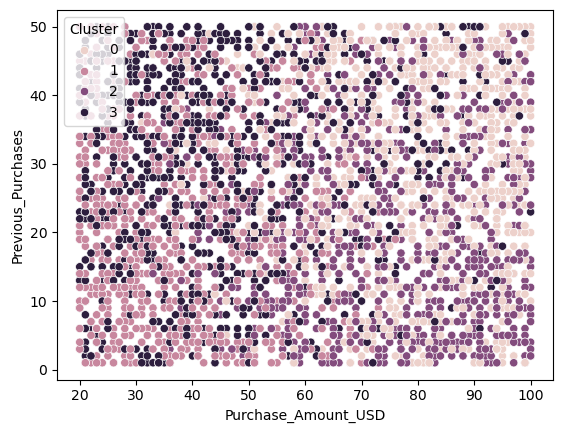

In [54]:
import seaborn as sns

sns.scatterplot(
    x='Purchase_Amount_USD',
    y='Previous_Purchases',
    hue='Cluster',
    data=df
)
plt.show()


In [41]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [22]:
# Clean numeric columns

In [24]:
df['Purchase_Amount_USD'] = pd.to_numeric(df['Purchase_Amount_USD'], errors='coerce')
df['Review_Rating'] = pd.to_numeric(df['Review_Rating'], errors='coerce')
df['Previous_Purchases'] = pd.to_numeric(df['Previous_Purchases'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [30]:
# standardize boolean columns text
df['Discount_Applied'] = df['Discount_Applied'].astype(str).str.strip()
df['Promo_Code_Used'] = df['Promo_Code_Used'].astype(str).str.strip()
df['Payment_Method'] = df['Payment_Method'].astype(str).str.strip()

In [31]:
# Category-wise metrics table

In [33]:
cat_metrics = df.groupby('Category').agg(
    tx_count = ('Customer_ID','count'),
    avg_spend = ('Purchase_Amount_USD','mean'),
    median_spend = ('Purchase_Amount_USD','median'),
    avg_rating = ('Review_Rating','mean'),
    discount_rate = ('Discount_Applied', lambda x: np.mean(x.str.lower()=='yes')),
    promo_rate = ('Promo_Code_Used', lambda x: np.mean(x.str.lower()=='yes'))
).reset_index()

In [35]:
# Round for readability
cat_metrics['avg_spend'] = cat_metrics['avg_spend'].round(2)
cat_metrics['median_spend'] = cat_metrics['median_spend'].round(2)
cat_metrics['avg_rating'] = cat_metrics['avg_rating'].round(2)
cat_metrics['discount_rate'] = (cat_metrics['discount_rate']*100).round(1)
cat_metrics['promo_rate'] = (cat_metrics['promo_rate']*100).round(1)

In [36]:
# Show whole table (or head)
display(cat_metrics.sort_values('tx_count', ascending=False).reset_index(drop=True))

,Category,tx_count,avg_spend,median_spend,avg_rating,discount_rate,promo_rate
0,Clothing,1737,60.03,60.0,3.72,42.1,42.1
1,Accessories,1240,59.84,60.0,3.77,43.8,43.8
2,Footwear,599,60.26,60.0,3.79,43.2,43.2
3,Outerwear,324,57.17,54.5,3.75,44.4,44.4


In [44]:
# save
cat_metrics.to_csv('category_metrics_summary.csv', index=False)

In [48]:
# average purchase amount is less and review rating is less
cat_metrics.to_csv(
    r'C:\Users\OMKAR\Documents\category_metrics_summary.csv',
    index=False
)

In [50]:
# Charts: Category vs Avg Spend & Category vs Discount Usage %
#  Plot top categories (by tx_count) for clarity

In [53]:
top_n = 12
top_cats = cat_metrics.sort_values('tx_count', ascending=False).head(top_n)['Category'].tolist()
plot_df = cat_metrics[cat_metrics['Category'].isin(top_cats)].set_index('Category').loc[top_cats]

In [55]:
# Chart 1: Category vs Avg Spend USD - Top Categories

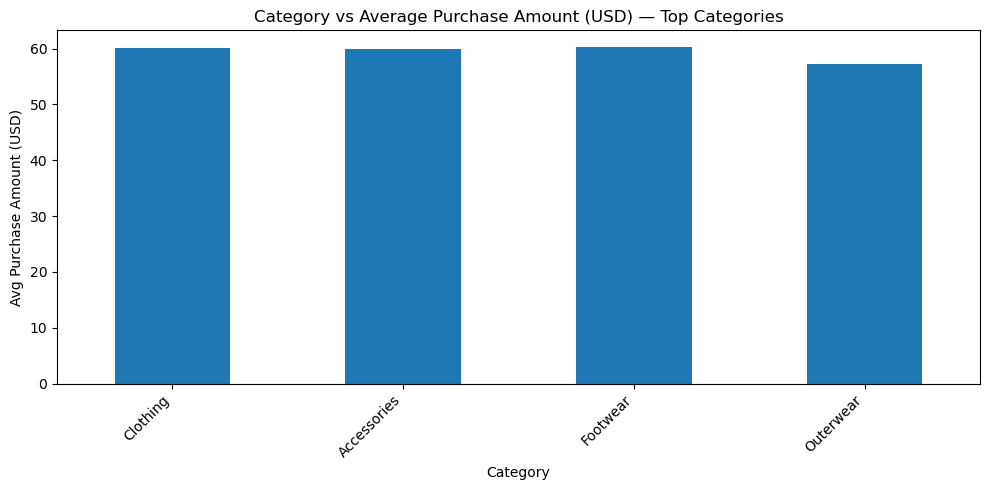

In [57]:
plt.figure(figsize=(10,5))
ax = plt.gca()
plot_df['avg_spend'].plot(kind='bar', ax=ax)
ax.set_title('Category vs Average Purchase Amount (USD) — Top Categories')
ax.set_ylabel('Avg Purchase Amount (USD)')
ax.set_xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [58]:
# Chart 2: Category vs Discount Usage %

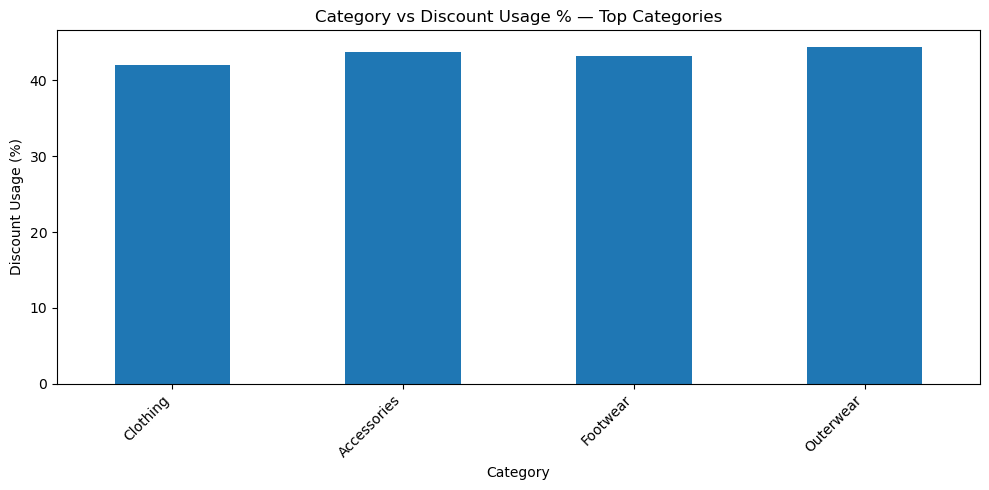

In [59]:
plt.figure(figsize=(10,5))
ax = plt.gca()
plot_df['discount_rate'].plot(kind='bar', ax=ax)
ax.set_title('Category vs Discount Usage % — Top Categories')
ax.set_ylabel('Discount Usage (%)')
ax.set_xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [60]:
# Identify categories with low avg spend & low rating (recommend discounts)

In [63]:
overall_avg_spend = cat_metrics['avg_spend'].mean()
overall_avg_rating = cat_metrics['avg_rating'].mean()

In [64]:
low_spend_low_rating = cat_metrics[
    (cat_metrics['avg_spend'] < overall_avg_spend) &
    (cat_metrics['avg_rating'] < overall_avg_rating)
].sort_values(['avg_spend','avg_rating'])

In [66]:
print("Overall avg spend:", round(overall_avg_spend,2), "Overall avg rating:", round(overall_avg_rating,2))
display(low_spend_low_rating[['Category','tx_count','avg_spend','avg_rating','discount_rate','promo_rate']])

Overall avg spend: 59.32 Overall avg rating: 3.76


,Category,tx_count,avg_spend,avg_rating,discount_rate,promo_rate
3,Outerwear,324,57.17,3.75,44.4,44.4


In [67]:
# categories with high discount/promo_code usage

In [68]:
high_discount = cat_metrics.sort_values('discount_rate', ascending=False).head(10)
print("\nTop categories by discount usage (monitor effectiveness):")
display(high_discount[['Category','tx_count','avg_spend','avg_rating','discount_rate','promo_rate']])


Top categories by discount usage (monitor effectiveness):


,Category,tx_count,avg_spend,avg_rating,discount_rate,promo_rate
3,Outerwear,324,57.17,3.75,44.4,44.4
0,Accessories,1240,59.84,3.77,43.8,43.8
2,Footwear,599,60.26,3.79,43.2,43.2
1,Clothing,1737,60.03,3.72,42.1,42.1


In [90]:
# Age group vs Card spending + Season & Location summaries
# Age-group vs card spend (table) and Season / Location how changes summary.

In [71]:
#  Card flag
df['is_card'] = df['Payment_Method'].str.lower().str.contains('card')

In [72]:
# Age groups
def age_group(age):
    try: age = float(age)
    except: return 'Unknown'
    if age < 18: return '<18'
    if 18 <= age <= 30: return 'Young (18-30)'
    if 31 <= age <= 50: return 'Middle (31-50)'
    return 'Senior (50+)'
df['age_group'] = df['Age'].apply(age_group)

In [75]:
# df['age_group']
df.age_group


0         Senior (50+)
1        Young (18-30)
2       Middle (31-50)
3        Young (18-30)
4       Middle (31-50)
             ...      
3895    Middle (31-50)
3896      Senior (50+)
3897    Middle (31-50)
3898    Middle (31-50)
3899      Senior (50+)
Name: age_group, Length: 3900, dtype: object

In [76]:
# Age-group card spending

In [83]:
age_card = df[df['is_card']].groupby('age_group').agg(
    card_tx = ('Customer_ID','count'),
    total_card_spent = ('Purchase_Amount_USD','sum'),
    avg_card_spent = ('Purchase_Amount_USD','mean')
).reset_index()
age_overall = df.groupby('age_group').agg(total_spent=('Purchase_Amount_USD','sum')).reset_index()
age_card = age_card.merge(age_overall, on='age_group', how='left')
age_card['card_spend_share_pct'] = (age_card['total_card_spent']/age_card['total_spent']*100).round(1)


In [82]:
display(age_card.sort_values('total_card_spent', ascending=False))
age_card.to_csv('age_card_spending.csv', index=False)

,age_group,card_tx,total_card_spent,avg_card_spent,total_spent,card_spend_share_pct
0,Middle (31-50),518,31097,60.032819,87322,35.6
1,Senior (50+),491,29475,60.030550,88480,33.3
2,Young (18-30),320,19113,59.728125,57279,33.4


In [84]:
# Season-wise card usage

In [86]:
season_card = df[df['is_card']].groupby('Season').agg(
    card_tx=('Customer_ID','count'),
    total_card_spent=('Purchase_Amount_USD','sum')
).reset_index().sort_values('total_card_spent', ascending=False)

display(season_card)
season_card.to_csv('season_card_spending.csv', index=False)

,Season,card_tx,total_card_spent
0,Fall,355,21694
3,Winter,337,20885
1,Spring,328,19099
2,Summer,309,18007


In [87]:
# Location-wise card preference (card spend share)
# Purpose Age-group vs card spend (table) and Season / Location how changes summary.

In [88]:
loc_total = df.groupby('Location').agg(total_spend=('Purchase_Amount_USD','sum'), total_tx=('Customer_ID','count')).reset_index()
loc_card_spend = df[df['is_card']].groupby('Location').agg(card_spend=('Purchase_Amount_USD','sum'), card_tx=('Customer_ID','count')).reset_index()
loc_card = loc_total.merge(loc_card_spend, on='Location', how='left').fillna(0)
loc_card['card_spend_share_pct'] = (loc_card['card_spend']/loc_card['total_spend']*100).replace([np.inf,-np.inf],0).fillna(0).round(1)
loc_card = loc_card.sort_values('card_spend_share_pct', ascending=False)

In [89]:
display(loc_card.head(20))
loc_card.head(50).to_csv('top_locations_card_share.csv', index=False)

,Location,total_spend,total_tx,card_spend,card_tx,card_spend_share_pct
43,Utah,4443,71,2036,32,45.8
41,Tennessee,4772,77,2118,35,44.4
33,North Dakota,5220,83,2290,34,43.9
12,Illinois,5617,92,2443,38,43.5
28,New Hampshire,4219,71,1804,30,42.8
32,North Carolina,4742,78,2026,35,42.7
25,Montana,5784,96,2445,38,42.3
16,Kentucky,4402,79,1827,32,41.5
14,Iowa,4201,69,1708,27,40.7
39,South Carolina,4439,76,1780,29,40.1


In [91]:
# Clustering (3 groups) + cluster profiling + dominant factors

In [93]:
# Map frequency strings to approximate times per year

freq_map = {
    'Weekly':52, 'weekly':52, 'Fortnightly':26, 'Fortnightly ':26, 'Bi-Weekly':26, 'Biweekly':26,
    'Monthly':12, 'Quarterly':4, 'Annually':1, 'Every 3 Months':4
}

In [94]:
df['freq_num'] = df['Frequency_of_Purchases'].map(lambda x: freq_map.get(str(x).strip(), np.nan))
df['freq_num'] = df['freq_num'].fillna(df['freq_num'].median())

In [95]:
cluster_features = df.groupby('Customer_ID').agg(
    age = ('Age','mean'),
    total_spent = ('Purchase_Amount_USD','sum'),
    avg_spent = ('Purchase_Amount_USD','mean'),
    prev_purchases = ('Previous_Purchases','mean'),
    avg_rating = ('Review_Rating','mean'),
    freq_num = ('freq_num','mean')
).reset_index().fillna(0)

In [96]:
X = cluster_features[['total_spent','freq_num','prev_purchases','avg_rating','age']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [97]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
cluster_features['cluster'] = cluster_labels

In [98]:
cluster_profile = cluster_features.groupby('cluster')[['total_spent','freq_num','prev_purchases','avg_rating','age']].mean().round(2)
cluster_size = cluster_features['cluster'].value_counts().sort_index()

In [100]:
print("Cluster sizes:", cluster_size.to_dict())
display(cluster_profile)
cluster_profile.to_csv('cluster_profile.csv', index=True)

Cluster sizes: {0: 1685, 1: 1676, 2: 539}


,total_spent,freq_num,prev_purchases,avg_rating,age
cluster,,,,,
0,80.29,11.97,25.61,3.85,44.03
1,39.38,11.90,24.95,3.65,43.92
2,58.97,52.00,25.77,3.76,44.65


In [101]:
# Dominant factors: compare range across cluster means normalized by feature std

In [102]:
feature_means = cluster_profile.copy()
global_std = X.std(axis=0)
feature_ranges = (feature_means.max() - feature_means.min()).abs()
dominance_score = feature_ranges / (global_std + 1e-9)
dominance = pd.DataFrame({
    'feature': ['total_spent','freq_num','prev_purchases','avg_rating','age'],
    'range': feature_ranges.values,
    'global_std': global_std,
    'dominance_score': dominance_score.values
}).sort_values('dominance_score', ascending=False).reset_index(drop=True)

In [104]:
display(dominance)
dominance.to_csv('cluster_dominance_scores.csv', index=False)

,feature,range,global_std,dominance_score
0,freq_num,40.10,16.809646,2.385535
1,total_spent,40.91,23.685392,1.727225
2,avg_rating,0.20,0.716223,0.279243
3,prev_purchases,0.82,14.447125,0.056759
4,age,0.73,15.207589,0.048002


In [108]:
# 2D PCA scatter for visualization
# Generated 3 clusters and the dominance table highlights which features differentiate the clusters the most
# (i.e., the dominant factors)

In [106]:
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X_scaled)
cluster_features['pc1'] = pc[:,0]; cluster_features['pc2'] = pc[:,1]

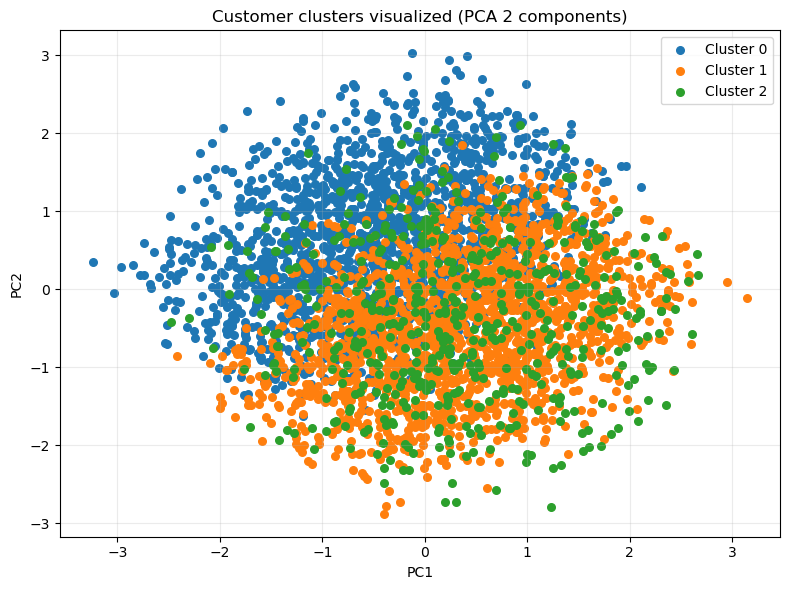

In [107]:
plt.figure(figsize=(8,6))
for cl in sorted(cluster_features['cluster'].unique()):
    subset = cluster_features[cluster_features['cluster']==cl]
    plt.scatter(subset['pc1'], subset['pc2'], label=f'Cluster {cl}', s=30)
plt.title('Customer clusters visualized (PCA 2 components)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()